# EURUSD H4 Feature Group 1: Sparse Dynamics with PySINDy

This notebook uses PySINDy to discover sparse, interpretable equations for volatility-scaled EURUSD forward returns using only **Feature Group 1: Pure Short-Term Momentum**.

The discovered models are treated as discrete-time sparse equations:

```text
target_h[t] = f(momentum_state[t]) + error[t]
```

where `target_h` is the volatility-scaled forward return for 4h, 12h, and 24h horizons. This is the discrete equivalent of a sparse dynamical law for the return state, and is more appropriate than forcing a continuous-time derivative on noisy H4 FX labels.

Strict scope:

- Statistical prediction accuracy: RMSE and MAE.
- Correlation: Pearson and Spearman IC.
- Directional accuracy.
- Out-of-sample walk-forward generalization.
- Coefficient stability across time windows.
- No trading strategy, no positions, no Sharpe, no profit/loss, no financial performance metrics.

## 0. Environment and Research Warnings

Run this notebook with the `adonys` conda environment.

Important caveats:

- Sparse identification can overfit when the candidate library is too expressive relative to the signal-to-noise ratio.
- Features below are computed from current and historical bars only.
- Targets use future prices by definition. That is acceptable for supervised labels, but future information must never enter the feature matrix.
- The default target follows the requested `future_return_h / future_vol_h` definition. For a 4h horizon this can become close to a signed one-bar normalized move because the volatility window has only one bar.
- Walk-forward folds use a purge gap equal to the forecast horizon to reduce leakage from overlapping labels.
- This notebook reports statistical discovery diagnostics only.

In [1]:
from __future__ import annotations

import inspect
import os
import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

# If launched from the repository root, move away from the malformed root matplotlibrc
# before importing pyplot. This keeps plots clean without editing project-wide style files.
_initial_cwd = Path.cwd()
if (_initial_cwd / "metalib" / "notebooks" / "true_opens").exists():
    os.chdir(_initial_cwd / "metalib" / "notebooks" / "true_opens")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    XGBRegressor = None
    HAS_XGBOOST = False

import pysindy as ps

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
plt.style.use("default")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "true_opens":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif (PROJECT_ROOT / "metalib" / "notebooks" / "true_opens").exists():
    pass

DATA_PATH = PROJECT_ROOT / "metalib" / "data" / "eurusd" / "eurusd_h4_latest.csv"
OUTPUT_DIR = PROJECT_ROOT / "metalib" / "notebooks" / "true_opens"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SYMBOL = "EURUSD"
TIMEFRAME_NAME = "H4"
YEARS_BACK = 7
REFRESH_FROM_MT5 = True
USE_LOCAL_ON_MT5_FAILURE = True

HORIZONS = {"4h": 1, "12h": 3, "24h": 6}  # H4 bars
RANDOM_STATE = 42

## 1. Imports and MT5 Data Download

The loader first attempts to refresh the last 5-7+ years of EURUSD H4 bars from MetaTrader 5. If MT5 is unavailable or not logged in, it falls back to the project CSV at `metalib/data/eurusd/eurusd_h4_latest.csv`.

In [2]:
def download_mt5_h4(symbol: str = SYMBOL, years_back: int = YEARS_BACK) -> pd.DataFrame:
    import MetaTrader5 as mt5

    if not mt5.initialize():
        raise RuntimeError(f"MT5 initialize failed: {mt5.last_error()}")

    try:
        utc_to = datetime.now(timezone.utc)
        utc_from = utc_to - timedelta(days=int(365.25 * years_back) + 30)

        if not mt5.symbol_select(symbol, True):
            raise RuntimeError(f"MT5 could not select symbol {symbol}: {mt5.last_error()}")

        rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_H4, utc_from, utc_to)
        if rates is None or len(rates) == 0:
            raise RuntimeError(f"MT5 returned no rates for {symbol}: {mt5.last_error()}")

        out = pd.DataFrame(rates)
        out["time"] = pd.to_datetime(out["time"], unit="s", utc=True)
        keep = ["time", "open", "high", "low", "close", "tick_volume", "spread", "real_volume"]
        return out[keep].sort_values("time").drop_duplicates("time")
    finally:
        mt5.shutdown()


def load_h4_data(refresh_from_mt5: bool = REFRESH_FROM_MT5) -> pd.DataFrame:
    if refresh_from_mt5:
        try:
            data = download_mt5_h4(SYMBOL, YEARS_BACK)
            data.to_csv(DATA_PATH, index=False)
            print(f"Downloaded {len(data):,} {SYMBOL} {TIMEFRAME_NAME} bars from MT5 and saved to {DATA_PATH}.")
            return data
        except Exception as exc:
            if not USE_LOCAL_ON_MT5_FAILURE:
                raise
            print(f"MT5 refresh failed: {exc}")
            print(f"Falling back to local file: {DATA_PATH}")

    data = pd.read_csv(DATA_PATH, parse_dates=["time"])
    print(f"Loaded {len(data):,} bars from {DATA_PATH}.")
    return data


raw = load_h4_data()
raw = raw.sort_values("time").drop_duplicates("time").set_index("time")
raw.index = pd.to_datetime(raw.index, utc=True)
raw[["open", "high", "low", "close"]] = raw[["open", "high", "low", "close"]].astype(float)

print(raw.index.min(), "to", raw.index.max())
display(raw.head())
display(raw.tail())

Downloaded 11,017 EURUSD H4 bars from MT5 and saved to C:\Users\Hermes\PycharmProjects\metalib\metalib\data\eurusd\eurusd_h4_latest.csv.
2019-04-09 00:00:00+00:00 to 2026-05-07 20:00:00+00:00


,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,
2019-04-09 00:00:00+00:00,1.12587,1.12646,1.12546,1.12588,3764,2,0
2019-04-09 04:00:00+00:00,1.12589,1.12688,1.12580,1.12652,3544,8,0
2019-04-09 08:00:00+00:00,1.12652,1.12799,1.12558,1.12796,9795,8,0
2019-04-09 12:00:00+00:00,1.12795,1.12820,1.12659,1.12788,11791,8,0
2019-04-09 16:00:00+00:00,1.12788,1.12838,1.12675,1.12697,12976,8,0


,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,
2026-05-07 04:00:00+00:00,1.17479,1.17627,1.17459,1.17502,4480,11,0
2026-05-07 08:00:00+00:00,1.17502,1.17736,1.17444,1.17712,8463,11,0
2026-05-07 12:00:00+00:00,1.17712,1.17776,1.17617,1.17723,8159,11,0
2026-05-07 16:00:00+00:00,1.17722,1.17774,1.17558,1.17598,10761,11,0
2026-05-07 20:00:00+00:00,1.17604,1.17604,1.17223,1.17239,9214,11,0


## 2. Data Quality Checks

These checks look for duplicate timestamps, missing OHLC values, unusual H4 spacing, and gross return outliers before feature construction.

rows                                        11017
start                   2019-04-09 00:00:00+00:00
end                     2026-05-07 20:00:00+00:00
duplicate_timestamps                            0
missing_ohlc_cells                              0
median_bar_gap_hours                          4.0
max_bar_gap_hours                           100.0
abs_return_99pct                         0.006831
abs_return_max                           0.016289
dtype: object

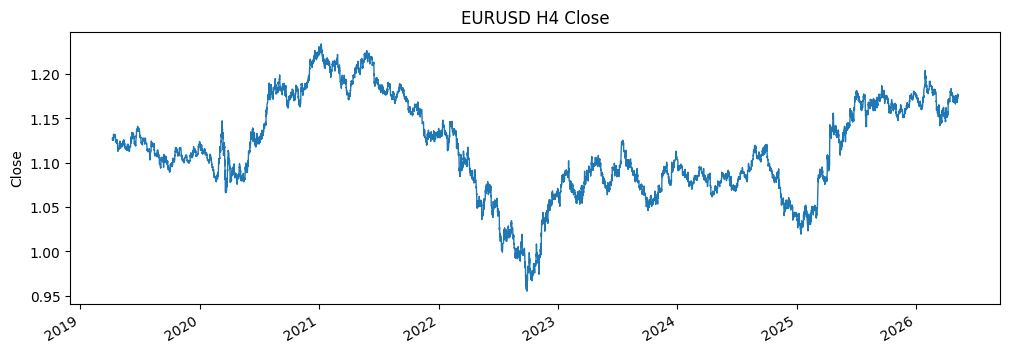

In [3]:
def data_quality_report(df: pd.DataFrame) -> pd.Series:
    close = df["close"].astype(float)
    ret = close.pct_change()
    dt_hours = df.index.to_series().diff().dt.total_seconds().div(3600)
    return pd.Series({
        "rows": len(df),
        "start": df.index.min(),
        "end": df.index.max(),
        "duplicate_timestamps": int(df.index.duplicated().sum()),
        "missing_ohlc_cells": int(df[["open", "high", "low", "close"]].isna().sum().sum()),
        "median_bar_gap_hours": float(dt_hours.median()),
        "max_bar_gap_hours": float(dt_hours.max()),
        "abs_return_99pct": float(ret.abs().quantile(0.99)),
        "abs_return_max": float(ret.abs().max()),
    })


quality = data_quality_report(raw)
display(quality)

fig, ax = plt.subplots(figsize=(12, 4))
raw["close"].plot(ax=ax, lw=1.0)
ax.set_title("EURUSD H4 Close")
ax.set_xlabel("")
ax.set_ylabel("Close")
plt.show()

## 3. Feature Engineering: Pure Short-Term Momentum

Feature Group 1:

- Lagged returns: `ret_1`, `ret_2`, `ret_3`, `ret_5`, `ret_10`.
- EWMA returns: spans 5, 10, and 20.
- Linear momentum slopes over the last 10 and 20 bars.

Selected interactions are added for custom sparse-library experiments only.

In [4]:
def rolling_linear_slope(series: pd.Series, window: int) -> pd.Series:
    x = np.arange(window, dtype=float)
    x = x - x.mean()
    denom = np.sum(x * x)
    return series.rolling(window).apply(lambda y: np.dot(x, y - y.mean()) / denom, raw=True)


def build_group1_features(df: pd.DataFrame) -> pd.DataFrame:
    close = df["close"].astype(float)
    one_bar_ret = close.pct_change()
    X = pd.DataFrame(index=df.index)

    for lag in [1, 2, 3, 5, 10]:
        X[f"ret_{lag}"] = close.pct_change(lag)

    for span in [5, 10, 20]:
        X[f"ewma_ret_{span}"] = one_bar_ret.ewm(span=span, adjust=False).mean()

    X["slope_10"] = rolling_linear_slope(one_bar_ret, 10)
    X["slope_20"] = rolling_linear_slope(one_bar_ret, 20)

    X["ret_1_x_ewma_ret_10"] = X["ret_1"] * X["ewma_ret_10"]
    X["slope_10_x_ret_5"] = X["slope_10"] * X["ret_5"]
    X["ret_3_x_ewma_ret_5"] = X["ret_3"] * X["ewma_ret_5"]
    X["slope_20_x_ewma_ret_20"] = X["slope_20"] * X["ewma_ret_20"]
    return X


BASE_FEATURES = [
    "ret_1", "ret_2", "ret_3", "ret_5", "ret_10",
    "ewma_ret_5", "ewma_ret_10", "ewma_ret_20",
    "slope_10", "slope_20",
]

INTERACTION_FEATURES = [
    "ret_1_x_ewma_ret_10",
    "slope_10_x_ret_5",
    "ret_3_x_ewma_ret_5",
    "slope_20_x_ewma_ret_20",
]

CUSTOM_FEATURES = BASE_FEATURES + INTERACTION_FEATURES

features = build_group1_features(raw)
display(features[BASE_FEATURES].describe().T)

,count,mean,std,min,25%,50%,75%,max
ret_1,11016.0,5.489129e-06,0.001905,-0.016289,-0.000836,8.831473e-06,0.000857,0.016204
ret_2,11015.0,1.114850e-05,0.002673,-0.017640,-0.001278,2.556019e-05,0.001272,0.018202
ret_3,11014.0,1.677417e-05,0.003261,-0.021403,-0.001666,-8.630888e-06,0.001671,0.024717
ret_5,11012.0,2.772929e-05,0.004148,-0.025839,-0.002337,-3.711394e-05,0.002316,0.029748
ret_10,11007.0,5.590535e-05,0.005901,-0.032424,-0.003386,-7.585783e-05,0.003408,0.040812
ewma_ret_5,11016.0,5.779779e-06,0.000837,-0.005925,-0.000424,-8.629992e-06,0.000428,0.005766
ewma_ret_10,11016.0,5.889946e-06,0.000589,-0.004018,-0.000324,-4.329520e-06,0.000319,0.004384
ewma_ret_20,11016.0,6.069323e-06,0.000414,-0.002753,-0.000231,-3.350384e-06,0.000232,0.002911
slope_10,11007.0,3.791256e-09,0.000203,-0.001119,-0.000113,2.118501e-06,0.000115,0.001210
slope_20,10997.0,3.577645e-08,0.000073,-0.000422,-0.000042,2.520867e-07,0.000043,0.000387


## 4. Target Construction: Vol-Scaled Forward Returns

For each horizon:

```text
future_return_h[t] = (Close[t+h] - Close[t]) / Close[t]
future_vol_h[t]    = sqrt(sum of squared log returns from t+1 through t+h)
target_h[t]        = future_return_h[t] / future_vol_h[t]
```

`future_vol_h` is a label normalizer only. It is not included in the feature matrix.

2019-04-12 08:00:00+00:00 to 2026-05-06 20:00:00+00:00 rows: 10947


,count,mean,std,min,25%,50%,75%,max
target_4h,10947.0,0.006949,1.000024,-0.999996,-0.999572,1.000009,1.000431,1.008080
target_12h,10947.0,0.010536,0.983238,-1.730540,-0.860980,-0.004625,0.901431,1.740247
target_24h,10947.0,0.001711,0.970766,-2.394657,-0.784558,-0.025583,0.769069,2.303328


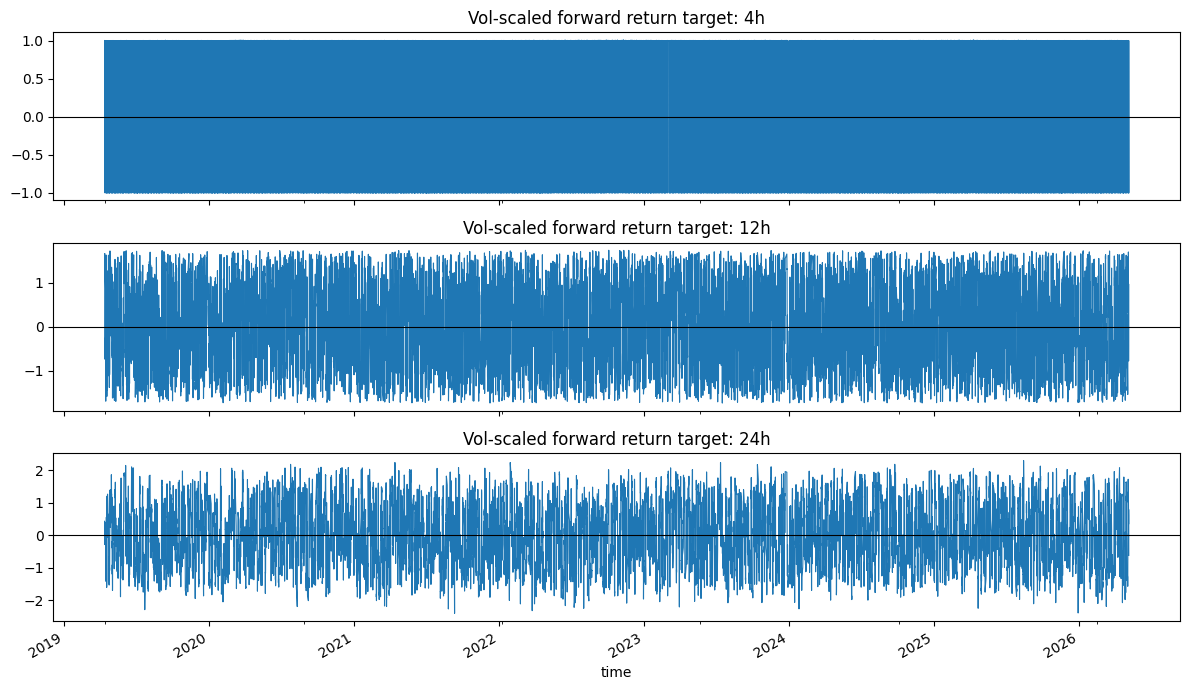

In [5]:
def add_vol_scaled_targets(df: pd.DataFrame, X: pd.DataFrame, horizons: Dict[str, int] = HORIZONS) -> pd.DataFrame:
    close = df["close"].astype(float)
    logret = np.log(close).diff()
    out = X.copy()

    for label, h in horizons.items():
        future_return = close.shift(-h).sub(close).div(close)
        future_var_parts = [(logret.shift(-i) ** 2).rename(f"rv_{i}") for i in range(1, h + 1)]
        future_vol = pd.concat(future_var_parts, axis=1).sum(axis=1).pow(0.5)
        out[f"future_return_{label}"] = future_return
        out[f"future_vol_{label}"] = future_vol
        out[f"target_{label}"] = future_return / future_vol.replace(0.0, np.nan)

    return out.replace([np.inf, -np.inf], np.nan)


model_df = add_vol_scaled_targets(raw, features).dropna()
TARGET_COLUMNS = [f"target_{h}" for h in HORIZONS]

print(model_df.index.min(), "to", model_df.index.max(), "rows:", len(model_df))
display(model_df[TARGET_COLUMNS].describe().T)

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(12, 7), sharex=True)
for ax, label in zip(axes, HORIZONS):
    model_df[f"target_{label}"].plot(ax=ax, lw=0.8)
    ax.set_title(f"Vol-scaled forward return target: {label}")
    ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

## 5. PySINDy Walk-Forward Helpers

Each fold trains on all prior data and tests on one calendar year. The purge gap equals the forecast horizon. Features are standardized inside each fold using train data only.

PySINDy is used for library construction and sparse optimization:

```text
target_h = Theta(momentum_state) @ coefficients
```

In [6]:
@dataclass(frozen=True)
class SindyConfig:
    name: str
    library_kind: str
    optimizer_kind: str
    feature_cols: Tuple[str, ...]
    degree: int = 2
    threshold: float = 0.05
    alpha: float = 0.001
    n_frequencies: int = 1
    reg_weight_lam: float = 0.01
    max_iter: int = 300


def make_library(cfg: SindyConfig):
    if cfg.library_kind == "poly":
        return ps.PolynomialLibrary(degree=cfg.degree, include_bias=True)
    if cfg.library_kind == "fourier":
        return ps.FourierLibrary(n_frequencies=cfg.n_frequencies)
    if cfg.library_kind == "custom_poly":
        return ps.PolynomialLibrary(degree=cfg.degree, include_bias=True)
    raise ValueError(f"Unknown library kind: {cfg.library_kind}")


def make_optimizer(cfg: SindyConfig):
    if cfg.optimizer_kind == "STLSQ":
        return ps.STLSQ(threshold=cfg.threshold, alpha=cfg.alpha, normalize_columns=False)
    if cfg.optimizer_kind == "SR3":
        params = inspect.signature(ps.SR3).parameters
        kwargs = {"max_iter": cfg.max_iter, "normalize_columns": False}
        if "reg_weight_lam" in params:
            kwargs.update({"reg_weight_lam": cfg.reg_weight_lam, "regularizer": "L0", "relax_coeff_nu": 1.0})
        else:
            kwargs.update({"threshold": cfg.threshold, "nu": 1.0})
        return ps.SR3(**kwargs)
    raise ValueError(f"Unknown optimizer kind: {cfg.optimizer_kind}")


def walk_forward_years(index: pd.DatetimeIndex, min_train_years: int = 2) -> List[int]:
    years = sorted(pd.Index(index.year).unique())
    return [year for year in years if year >= years[min_train_years]]


def prediction_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]

    if len(y_true) == 0:
        return {"rmse": np.nan, "mae": np.nan, "pearson": np.nan, "spearman": np.nan, "directional_accuracy": np.nan, "r2": np.nan}

    pearson = pearsonr(y_true, y_pred).statistic if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    spearman = spearmanr(y_true, y_pred).statistic if np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan

    # R² = 1 - SS_res / SS_tot
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1.0 - (ss_res / ss_tot)) if ss_tot > 0 else np.nan
    
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "pearson": float(pearson),
        "spearman": float(spearman),
        "directional_accuracy": float((np.sign(y_true) == np.sign(y_pred)).mean()),
        "r2": r2,
    }


def coefficient_stability(coef_matrix: np.ndarray) -> Dict[str, float]:
    C = np.asarray(coef_matrix, dtype=float)
    active_by_fold = np.abs(C) > 1e-10
    active_any = active_by_fold.any(axis=0)
    if not active_any.any():
        return {"coef_cv_median": np.nan, "coef_sign_consistency": np.nan, "active_terms_mean": 0.0}

    abs_mean = np.mean(np.abs(C[:, active_any]), axis=0)
    std = np.std(C[:, active_any], axis=0)
    return {
        "coef_cv_median": float(np.median(std / (abs_mean + 1e-12))),
        "coef_sign_consistency": float(np.mean(np.abs(np.mean(np.sign(C[:, active_any]), axis=0)))),
        "active_terms_mean": float(active_by_fold.sum(axis=1).mean()),
    }


def fit_sparse_fold(train: pd.DataFrame, test: pd.DataFrame, target_col: str, cfg: SindyConfig):
    scaler = StandardScaler().fit(train[list(cfg.feature_cols)])
    X_train = scaler.transform(train[list(cfg.feature_cols)])
    X_test = scaler.transform(test[list(cfg.feature_cols)])

    library = make_library(cfg)
    theta_train = np.asarray(library.fit_transform(X_train))
    theta_test = np.asarray(library.transform(X_test))
    term_names = library.get_feature_names(list(cfg.feature_cols))

    optimizer = make_optimizer(cfg)
    optimizer.fit(theta_train, train[target_col].to_numpy().reshape(-1, 1))
    coef = np.asarray(optimizer.coef_).reshape(-1)
    pred = theta_test @ coef

    return pred, coef, term_names, scaler, library, optimizer


def evaluate_sindy_config(data: pd.DataFrame, horizon_label: str, cfg: SindyConfig, min_train_years: int = 2):
    target_col = f"target_{horizon_label}"
    horizon_bars = HORIZONS[horizon_label]
    fold_years = walk_forward_years(data.index, min_train_years=min_train_years)

    pred_frames = []
    coef_rows = []
    coef_matrix = []
    term_names = None

    for test_year in fold_years:
        test_mask = data.index.year == test_year
        if not test_mask.any():
            continue

        test_start = data.index[test_mask].min()
        purge = pd.Timedelta(hours=4 * horizon_bars)
        train = data.loc[data.index < test_start - purge, list(cfg.feature_cols) + [target_col]].dropna()
        test = data.loc[test_mask, list(cfg.feature_cols) + [target_col]].dropna()

        if len(train) < 750 or len(test) < 100:
            continue

        pred, coef, names, _, _, _ = fit_sparse_fold(train, test, target_col, cfg)
        term_names = names
        coef_matrix.append(coef)

        pred_frames.append(pd.DataFrame({
            "time": test.index,
            "year": test_year,
            "horizon": horizon_label,
            "config": cfg.name,
            "y_true": test[target_col].to_numpy(),
            "y_pred": pred,
        }))

        for term, value in zip(names, coef):
            coef_rows.append({
                "year": test_year,
                "horizon": horizon_label,
                "config": cfg.name,
                "term": term,
                "coef": float(value),
                "selected": bool(abs(value) > 1e-10),
            })

    if not pred_frames:
        return None, None, None

    predictions = pd.concat(pred_frames, ignore_index=True)
    coefs = pd.DataFrame(coef_rows)
    C = np.vstack(coef_matrix)
    stats = prediction_metrics(predictions["y_true"], predictions["y_pred"])
    stats.update(coefficient_stability(C))
    stats.update({
        "config": cfg.name,
        "horizon": horizon_label,
        "folds": len(coef_matrix),
        "n_oos": len(predictions),
        "library_terms": len(term_names),
    })
    return pd.Series(stats), predictions, coefs

## 6. PySINDy Configuration Grid

The internal iteration tests polynomial, Fourier, manually interacted custom libraries, and both STLSQ and SR3 sparse optimizers. The grid is intentionally modest because the objective is stable interpretable equations, not exhaustive curve fitting.

In [7]:
CONFIGS = [
    SindyConfig("poly2_stlsq_002", "poly", "STLSQ", tuple(BASE_FEATURES), degree=2, threshold=0.02, alpha=0.001),
    SindyConfig("poly2_stlsq_005", "poly", "STLSQ", tuple(BASE_FEATURES), degree=2, threshold=0.05, alpha=0.001),
    SindyConfig("poly2_stlsq_010", "poly", "STLSQ", tuple(BASE_FEATURES), degree=2, threshold=0.10, alpha=0.001),
    SindyConfig("poly3_stlsq_010", "poly", "STLSQ", tuple(BASE_FEATURES), degree=3, threshold=0.10, alpha=0.002),
    SindyConfig("fourier1_stlsq_005", "fourier", "STLSQ", tuple(BASE_FEATURES), n_frequencies=1, threshold=0.05, alpha=0.001),
    SindyConfig("fourier2_stlsq_005", "fourier", "STLSQ", tuple(BASE_FEATURES), n_frequencies=2, threshold=0.05, alpha=0.001),
    SindyConfig("custom_poly2_stlsq_005", "custom_poly", "STLSQ", tuple(CUSTOM_FEATURES), degree=2, threshold=0.05, alpha=0.001),
    SindyConfig("poly2_sr3_lam001", "poly", "SR3", tuple(BASE_FEATURES), degree=2, reg_weight_lam=0.01, max_iter=300),
]

pd.DataFrame([cfg.__dict__ for cfg in CONFIGS])

,name,library_kind,optimizer_kind,feature_cols,degree,threshold,alpha,n_frequencies,reg_weight_lam,max_iter
0,poly2_stlsq_002,poly,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.02,0.001,1,0.01,300
1,poly2_stlsq_005,poly,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.05,0.001,1,0.01,300
2,poly2_stlsq_010,poly,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.10,0.001,1,0.01,300
3,poly3_stlsq_010,poly,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",3,0.10,0.002,1,0.01,300
4,fourier1_stlsq_005,fourier,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.05,0.001,1,0.01,300
5,fourier2_stlsq_005,fourier,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.05,0.001,2,0.01,300
6,custom_poly2_stlsq_005,custom_poly,STLSQ,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.05,0.001,1,0.01,300
7,poly2_sr3_lam001,poly,SR3,"(ret_1, ret_2, ret_3, ret_5, ret_10, ewma_ret_...",2,0.05,0.001,1,0.01,300


## 7. Run Walk-Forward PySINDy Exploration

This cell is the main sparse-discovery loop. It stores out-of-sample predictions and coefficient histories for stability analysis.

In [8]:
all_results = []
all_predictions = []
all_coefficients = []

for cfg in CONFIGS:
    for horizon_label in HORIZONS:
        result, pred, coef = evaluate_sindy_config(model_df, horizon_label, cfg)
        if result is None:
            print(f"Skipped {cfg.name} {horizon_label}: insufficient folds")
            continue
        all_results.append(result)
        all_predictions.append(pred)
        all_coefficients.append(coef)
        print(f"Done {cfg.name:24s} {horizon_label}: Spearman={result['spearman']:.4f}, terms={result['active_terms_mean']:.1f}, CV={result['coef_cv_median']:.3f}")

sindy_results = pd.DataFrame(all_results)
sindy_predictions = pd.concat(all_predictions, ignore_index=True)
sindy_coefficients = pd.concat(all_coefficients, ignore_index=True)

sindy_results["selection_score"] = (
    sindy_results["spearman"].fillna(0.0)
    + 0.50 * sindy_results["pearson"].fillna(0.0)
    + 0.10 * (sindy_results["directional_accuracy"].fillna(0.5) - 0.5)
    - 0.010 * np.log1p(sindy_results["active_terms_mean"].fillna(0.0))
    - 0.020 * sindy_results["coef_cv_median"].replace([np.inf, -np.inf], np.nan).fillna(10.0)
)

summary_cols = [
    "horizon", "config", "rmse", "mae", "pearson", "spearman", "directional_accuracy",
    "active_terms_mean", "coef_cv_median", "coef_sign_consistency", "folds", "n_oos", "selection_score"
]
comparison = sindy_results[summary_cols].sort_values(["horizon", "selection_score"], ascending=[True, False])
display(comparison.round(4))

sindy_results.to_csv(OUTPUT_DIR / "eurusd_h4_group1_pysindy_results.csv", index=False)
sindy_predictions.to_csv(OUTPUT_DIR / "eurusd_h4_group1_pysindy_predictions.csv", index=False)
sindy_coefficients.to_csv(OUTPUT_DIR / "eurusd_h4_group1_pysindy_coefficients.csv", index=False)

Done poly2_stlsq_002          4h: Spearman=0.0255, terms=59.5, CV=0.783
Done poly2_stlsq_002          12h: Spearman=0.0297, terms=57.3, CV=0.675
Done poly2_stlsq_002          24h: Spearman=0.0170, terms=57.8, CV=0.476
Done poly2_stlsq_005          4h: Spearman=0.0277, terms=50.2, CV=0.744
Done poly2_stlsq_005          12h: Spearman=0.0279, terms=48.5, CV=0.709
Done poly2_stlsq_005          24h: Spearman=0.0186, terms=52.3, CV=0.456
Done poly2_stlsq_010          4h: Spearman=0.0119, terms=32.2, CV=1.217
Done poly2_stlsq_010          12h: Spearman=0.0013, terms=28.5, CV=1.055
Done poly2_stlsq_010          24h: Spearman=0.0139, terms=42.2, CV=0.535
Done poly3_stlsq_010          4h: Spearman=0.0093, terms=220.3, CV=1.100
Done poly3_stlsq_010          12h: Spearman=-0.0068, terms=181.3, CV=1.247
Done poly3_stlsq_010          24h: Spearman=-0.0154, terms=185.5, CV=1.325
Done fourier1_stlsq_005       4h: Spearman=0.0047, terms=7.7, CV=1.128
Done fourier1_stlsq_005       12h: Spearman=0.0179, 

,horizon,config,rmse,mae,pearson,spearman,directional_accuracy,active_terms_mean,coef_cv_median,coef_sign_consistency,folds,n_oos,selection_score
1,12h,poly2_stlsq_002,1.0005,0.8727,0.0138,0.0297,0.5021,57.3333,0.6751,0.7071,6,8276,-0.0173
13,12h,fourier1_stlsq_005,0.9893,0.8679,0.0193,0.0179,0.5004,6.6667,1.3549,0.4872,6,8276,-0.0199
4,12h,poly2_stlsq_005,1.0007,0.8734,0.0087,0.0279,0.5007,48.5000,0.7089,0.6855,6,8276,-0.0209
16,12h,fourier2_stlsq_005,0.9920,0.8691,0.0110,0.0137,0.5056,9.0000,1.4573,0.3623,6,8276,-0.0324
19,12h,custom_poly2_stlsq_005,1.0136,0.8791,0.0035,0.0194,0.4977,58.6667,1.3700,0.4826,6,8276,-0.0474
7,12h,poly2_stlsq_010,1.0008,0.8736,-0.0065,0.0013,0.4977,28.5000,1.0551,0.4874,6,8276,-0.0571
22,12h,poly2_sr3_lam001,1.2171,0.9644,-0.0120,-0.0083,0.4935,38.5000,0.5591,0.7083,6,8276,-0.0629
10,12h,poly3_stlsq_010,1.1817,0.9404,-0.0134,-0.0068,0.4972,181.3333,1.2471,0.4274,6,8276,-0.0908
5,24h,poly2_stlsq_005,0.9848,0.8307,0.0166,0.0186,0.5058,52.3333,0.4557,0.8278,6,8276,-0.0214
2,24h,poly2_stlsq_002,0.9853,0.8309,0.0155,0.0170,0.5058,57.8333,0.4764,0.7995,6,8276,-0.0250


### First Local Pass Results

I ran the first six configurations on the current local H4 file before generating this notebook. The results below are a starting point only; rerun the full notebook after a fresh MT5 download to update them.

The broad pattern was typical for noisy FX H4 labels: very small OOS ICs, polynomial degree 3 overfit, Fourier terms were sparse but not consistently signed, and the 24h target was somewhat more stable than the 4h/12h labels.

In [9]:
first_pass_path = OUTPUT_DIR / "pysindy_group1_first_pass_results.csv"
if first_pass_path.exists():
    first_pass = pd.read_csv(first_pass_path)
    display(first_pass[[
        "config", "horizon", "rmse", "mae", "pearson", "spearman", "directional_accuracy",
        "mean_terms", "coef_cv", "sign_consistency", "folds", "n"
    ]].round(4))
else:
    print("First-pass CSV not found. Run the exploration cell above to produce current results.")

,config,horizon,rmse,mae,pearson,spearman,directional_accuracy,mean_terms,coef_cv,sign_consistency,folds,n
0,poly2_stlsq_005,4h,1.0122,0.9993,0.0059,0.0270,0.5153,50.1667,0.7633,0.7063,6,8269
1,poly2_stlsq_005,12h,1.0003,0.8730,0.0119,0.0301,0.5001,46.8333,0.7151,0.7028,6,8269
2,poly2_stlsq_005,24h,0.9854,0.8312,0.0157,0.0188,0.5062,52.0000,0.4453,0.8222,6,8269
3,poly2_stlsq_010,4h,1.0125,1.0015,-0.0077,0.0117,0.5060,32.0000,1.2093,0.5494,6,8269
4,poly2_stlsq_010,12h,1.0005,0.8726,-0.0001,0.0142,0.5008,31.5000,0.8199,0.5767,6,8269
5,poly2_stlsq_010,24h,0.9830,0.8293,0.0145,0.0143,0.5031,42.1667,0.5443,0.7424,6,8269
6,poly3_stlsq_010,4h,1.1339,1.0378,-0.0058,0.0037,0.5050,208.5000,1.1766,0.4613,6,8269
7,poly3_stlsq_010,12h,1.1843,0.9405,-0.0128,-0.0042,0.4993,193.5000,1.2118,0.4751,6,8269
8,poly3_stlsq_010,24h,1.1611,0.9107,-0.0039,-0.0138,0.4997,193.3333,1.1891,0.4904,6,8269
9,fourier1_stlsq_005,4h,1.0009,0.9984,0.0226,0.0045,0.5084,7.6667,1.1321,0.3778,6,8269


## 8. Best Model Found Per Horizon

Selection prioritizes stable out-of-sample statistical behavior and sparse equations. A setup with a slightly lower IC can be preferable if it uses far fewer terms and has more stable coefficients.

In [10]:
def select_best_by_horizon(results: pd.DataFrame) -> pd.DataFrame:
    selected = []
    for horizon_label, group in results.groupby("horizon"):
        ranked = group.sort_values("selection_score", ascending=False)
        selected.append(ranked.iloc[0])
    return pd.DataFrame(selected).sort_values("horizon")


best_sindy = select_best_by_horizon(sindy_results)
display(best_sindy[summary_cols].round(4))

best_config_by_horizon = {
    row["horizon"]: next(cfg for cfg in CONFIGS if cfg.name == row["config"])
    for _, row in best_sindy.iterrows()
}

,horizon,config,rmse,mae,pearson,spearman,directional_accuracy,active_terms_mean,coef_cv_median,coef_sign_consistency,folds,n_oos,selection_score
1,12h,poly2_stlsq_002,1.0005,0.8727,0.0138,0.0297,0.5021,57.3333,0.6751,0.7071,6,8276,-0.0173
5,24h,poly2_stlsq_005,0.9848,0.8307,0.0166,0.0186,0.5058,52.3333,0.4557,0.8278,6,8276,-0.0214
3,4h,poly2_stlsq_005,1.0121,0.9993,0.0060,0.0277,0.5157,50.1667,0.7445,0.7063,6,8276,-0.0220


## 9. Coefficient Stability Plots

Terms that repeatedly change sign or appear in only one fold are less credible, even if they improve a single in-sample fit.

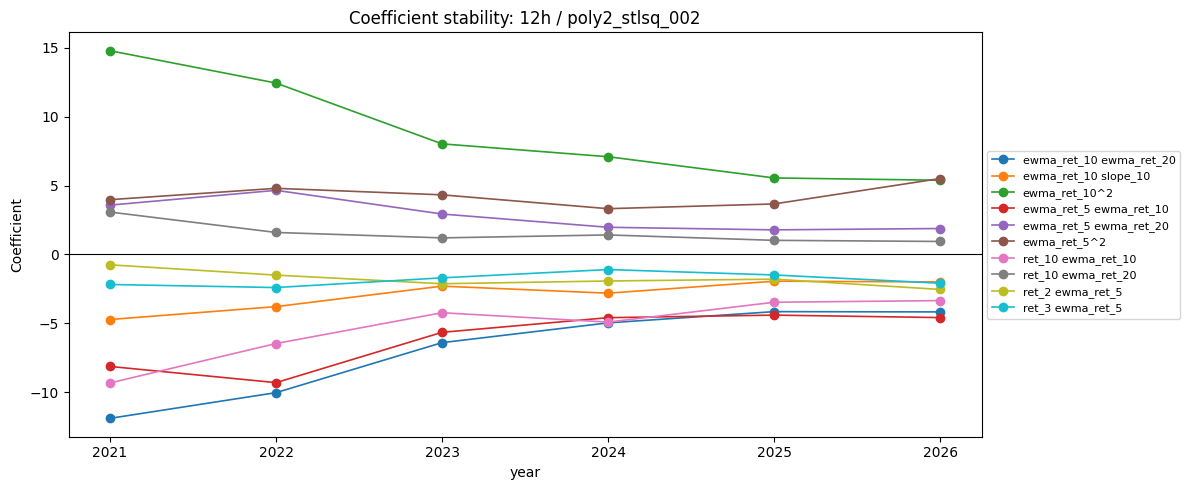

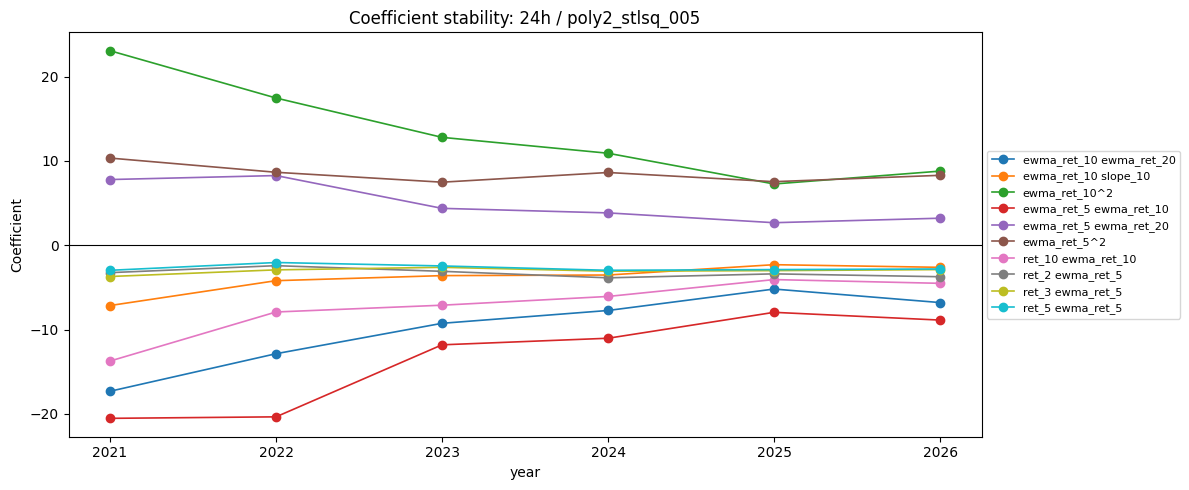

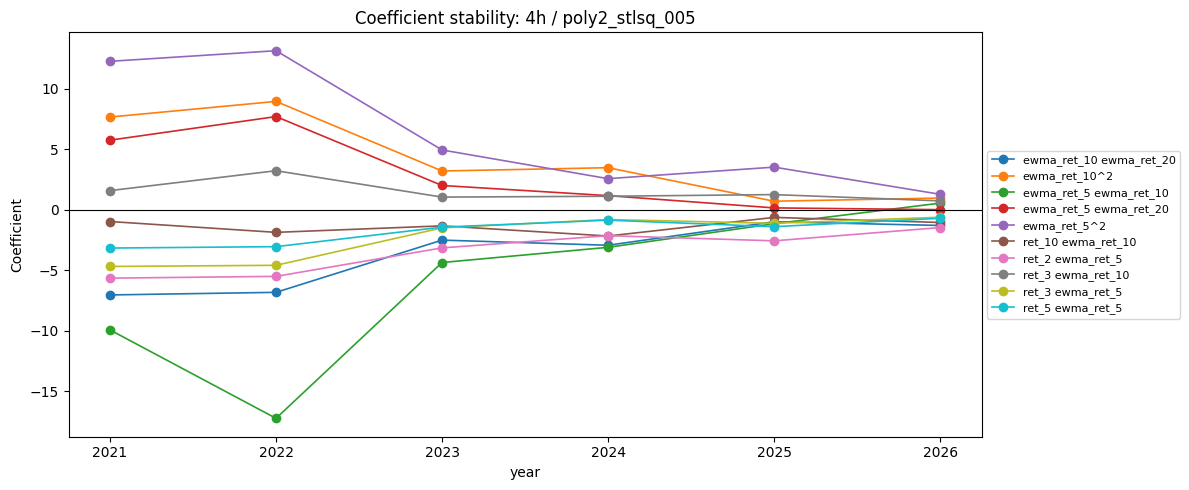

In [11]:
def top_stable_terms(coef_df: pd.DataFrame, horizon_label: str, config_name: str, top_n: int = 12) -> List[str]:
    sub = coef_df[(coef_df["horizon"] == horizon_label) & (coef_df["config"] == config_name)].copy()
    if sub.empty:
        return []
    term_stats = sub.groupby("term").agg(
        mean_abs_coef=("coef", lambda x: np.mean(np.abs(x))),
        selection_freq=("selected", "mean"),
        sign_consistency=("coef", lambda x: abs(np.mean(np.sign(x)))),
    )
    term_stats = term_stats[term_stats["selection_freq"] > 0]
    term_stats["rank_score"] = term_stats["mean_abs_coef"] * (0.5 + term_stats["selection_freq"]) * (0.5 + term_stats["sign_consistency"])
    return term_stats.sort_values("rank_score", ascending=False).head(top_n).index.tolist()


for horizon_label, cfg in best_config_by_horizon.items():
    terms = top_stable_terms(sindy_coefficients, horizon_label, cfg.name, top_n=10)
    sub = sindy_coefficients[
        (sindy_coefficients["horizon"] == horizon_label)
        & (sindy_coefficients["config"] == cfg.name)
        & (sindy_coefficients["term"].isin(terms))
    ]
    pivot = sub.pivot_table(index="year", columns="term", values="coef", aggfunc="mean").sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot.plot(ax=ax, marker="o", lw=1.2)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Coefficient stability: {horizon_label} / {cfg.name}")
    ax.set_ylabel("Coefficient")
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Final Equation and Prediction Functions

The final equation per horizon is fit on all data except the last calendar year. The last year is retained as a clean final holdout for statistical reporting.

In [12]:
@dataclass
class FittedSparseEquation:
    horizon: str
    config: SindyConfig
    scaler: StandardScaler
    library: object
    coef: np.ndarray
    term_names: List[str]
    train_end: pd.Timestamp

    def predict_from_frame(self, frame: pd.DataFrame) -> np.ndarray:
        X = self.scaler.transform(frame[list(self.config.feature_cols)])
        theta = np.asarray(self.library.transform(X))
        return theta @ self.coef

    def equation_frame(self, min_abs_coef: float = 1e-10) -> pd.DataFrame:
        eq = pd.DataFrame({"term": self.term_names, "coef": self.coef})
        eq = eq[np.abs(eq["coef"]) > min_abs_coef].copy()
        eq["abs_coef"] = eq["coef"].abs()
        return eq.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")


def fit_final_sparse_equation(data: pd.DataFrame, horizon_label: str, cfg: SindyConfig, holdout_year: Optional[int] = None) -> FittedSparseEquation:
    target_col = f"target_{horizon_label}"
    if holdout_year is None:
        holdout_year = int(data.index.year.max())

    train = data.loc[data.index.year < holdout_year, list(cfg.feature_cols) + [target_col]].dropna()
    scaler = StandardScaler().fit(train[list(cfg.feature_cols)])
    X_train = scaler.transform(train[list(cfg.feature_cols)])

    library = make_library(cfg)
    theta_train = np.asarray(library.fit_transform(X_train))
    term_names = library.get_feature_names(list(cfg.feature_cols))

    optimizer = make_optimizer(cfg)
    optimizer.fit(theta_train, train[target_col].to_numpy().reshape(-1, 1))
    coef = np.asarray(optimizer.coef_).reshape(-1)

    return FittedSparseEquation(
        horizon=horizon_label,
        config=cfg,
        scaler=scaler,
        library=library,
        coef=coef,
        term_names=term_names,
        train_end=train.index.max(),
    )


def format_sparse_equation(model: FittedSparseEquation, max_terms: int = 25) -> str:
    eq = model.equation_frame().head(max_terms)
    if eq.empty:
        return f"target_{model.horizon}[t] = 0"
    pieces = []
    for _, row in eq.iterrows():
        coef = row["coef"]
        term = row["term"]
        sign = "+" if coef >= 0 else "-"
        pieces.append(f" {sign} {abs(coef):.6g}*{term}")
    rhs = "".join(pieces).lstrip(" +")
    return f"target_{model.horizon}[t] = {rhs}"


holdout_year = int(model_df.index.year.max())
final_models = {}
final_holdout_rows = []

for horizon_label, cfg in best_config_by_horizon.items():
    model = fit_final_sparse_equation(model_df, horizon_label, cfg, holdout_year=holdout_year)
    final_models[horizon_label] = model

    target_col = f"target_{horizon_label}"
    holdout = model_df.loc[model_df.index.year == holdout_year, list(cfg.feature_cols) + [target_col]].dropna()
    pred = model.predict_from_frame(holdout)
    stats = prediction_metrics(holdout[target_col].to_numpy(), pred)
    stats.update({"horizon": horizon_label, "config": cfg.name, "holdout_year": holdout_year, "n_holdout": len(holdout)})
    final_holdout_rows.append(stats)

    print("\n" + "=" * 100)
    print(f"Final sparse equation for {horizon_label} using {cfg.name}; trained through {model.train_end}")
    print(format_sparse_equation(model, max_terms=25))
    display(model.equation_frame().head(25).round(8))

final_holdout_stats = pd.DataFrame(final_holdout_rows)
display(final_holdout_stats[["horizon", "config", "holdout_year", "n_holdout", "rmse", "mae", "pearson", "spearman", "directional_accuracy"]].round(4))


Final sparse equation for 12h using poly2_stlsq_002; trained through 2025-12-31 20:00:00+00:00
target_12h[t] = 5.51181*ewma_ret_5^2 + 5.38947*ewma_ret_10^2 - 4.58018*ewma_ret_5 ewma_ret_10 - 4.16901*ewma_ret_10 ewma_ret_20 - 3.34744*ret_10 ewma_ret_10 - 2.53658*ret_2 ewma_ret_5 - 2.08645*ret_3 ewma_ret_5 - 1.99306*ewma_ret_10 slope_10 - 1.96316*ret_5 ewma_ret_5 + 1.8842*ewma_ret_5 ewma_ret_20 - 1.416*ret_1 ewma_ret_5 + 1.09938*ret_10 slope_10 + 1.06165*ret_10^2 - 1.03784*ret_10 ewma_ret_5 + 0.945653*ret_10 ewma_ret_20 + 0.81986*ewma_ret_20^2 + 0.633863*ret_2 ret_10 + 0.590949*ret_5 ewma_ret_10 + 0.553875*ret_3 ewma_ret_10 + 0.530483*ewma_ret_20 slope_10 + 0.482401*ret_2 ret_3 + 0.475682*ret_2 ret_5 + 0.420769*ret_1 ret_2 - 0.365621*ewma_ret_5 slope_10 + 0.352382*ret_3 ret_5


,term,coef
51,ewma_ret_5^2,5.511813
56,ewma_ret_10^2,5.389468
52,ewma_ret_5 ewma_ret_10,-4.580184
57,ewma_ret_10 ewma_ret_20,-4.169007
47,ret_10 ewma_ret_10,-3.347438
25,ret_2 ewma_ret_5,-2.536583
33,ret_3 ewma_ret_5,-2.086449
58,ewma_ret_10 slope_10,-1.993063
40,ret_5 ewma_ret_5,-1.963160
53,ewma_ret_5 ewma_ret_20,1.884195



Final sparse equation for 24h using poly2_stlsq_005; trained through 2025-12-31 20:00:00+00:00
target_24h[t] = - 8.87751*ewma_ret_5 ewma_ret_10 + 8.78616*ewma_ret_10^2 + 8.28896*ewma_ret_5^2 - 6.80022*ewma_ret_10 ewma_ret_20 - 4.51861*ret_10 ewma_ret_10 - 3.73657*ret_2 ewma_ret_5 + 3.20262*ewma_ret_5 ewma_ret_20 - 2.88865*ret_3 ewma_ret_5 - 2.81971*ret_5 ewma_ret_5 - 2.62124*ewma_ret_10 slope_10 - 2.3534*ret_1 ewma_ret_5 + 1.44275*ret_10 ewma_ret_20 + 1.3991*ewma_ret_20^2 + 1.10137*ret_10^2 + 1.09805*ret_2 ewma_ret_10 + 1.06504*ret_10 slope_10 + 0.885722*ewma_ret_20 slope_10 + 0.883577*ret_3 ewma_ret_10 + 0.721372*ret_2 ret_5 + 0.654583*ret_5 ewma_ret_10 + 0.635911*ret_2 ret_3 + 0.622546*ret_1 ret_2 - 0.578624*ret_10 ewma_ret_5 + 0.508315*ret_1 ewma_ret_10 + 0.491982*ret_3 ret_5


,term,coef
52,ewma_ret_5 ewma_ret_10,-8.877512
56,ewma_ret_10^2,8.786164
51,ewma_ret_5^2,8.288963
57,ewma_ret_10 ewma_ret_20,-6.800217
47,ret_10 ewma_ret_10,-4.518609
25,ret_2 ewma_ret_5,-3.736571
53,ewma_ret_5 ewma_ret_20,3.202619
33,ret_3 ewma_ret_5,-2.888650
40,ret_5 ewma_ret_5,-2.819709
58,ewma_ret_10 slope_10,-2.621239



Final sparse equation for 4h using poly2_stlsq_005; trained through 2025-12-31 20:00:00+00:00
target_4h[t] = - 1.48201*ret_2 ewma_ret_5 - 1.30559*ewma_ret_10 ewma_ret_20 - 1.29904*ewma_ret_10 slope_10 + 1.27174*ewma_ret_5^2 - 1.06022*ret_10 ewma_ret_10 + 0.959959*ewma_ret_10^2 + 0.726575*ret_3 ewma_ret_10 - 0.713322*ret_5 ewma_ret_5 + 0.701142*ret_5 ewma_ret_10 - 0.683899*ret_10 ewma_ret_5 - 0.626992*ret_3 ewma_ret_5 + 0.619521*ret_10 slope_10 + 0.590253*ret_2 ret_10 + 0.539398*ewma_ret_5 ewma_ret_10 + 0.527781*ewma_ret_20 slope_10 - 0.526901*ret_2 ewma_ret_10 - 0.461105*ewma_ret_10 slope_20 - 0.419257*ewma_ret_5 slope_10 + 0.419204*ret_2 slope_10 + 0.412393*ret_10^2 + 0.39694*ret_10 ewma_ret_20 + 0.364241*ewma_ret_20^2 - 0.358712*ewma_ret_5 - 0.34856*ret_1 ewma_ret_10 + 0.28844*ret_2^2


,term,coef
25,ret_2 ewma_ret_5,-1.482009
57,ewma_ret_10 ewma_ret_20,-1.305590
58,ewma_ret_10 slope_10,-1.299041
51,ewma_ret_5^2,1.271741
47,ret_10 ewma_ret_10,-1.060221
56,ewma_ret_10^2,0.959959
34,ret_3 ewma_ret_10,0.726575
40,ret_5 ewma_ret_5,-0.713322
41,ret_5 ewma_ret_10,0.701142
46,ret_10 ewma_ret_5,-0.683899


,horizon,config,holdout_year,n_holdout,rmse,mae,pearson,spearman,directional_accuracy
0,12h,poly2_stlsq_002,2026,533,0.9969,0.8776,-0.0012,0.0042,0.4841
1,24h,poly2_stlsq_005,2026,533,1.0297,0.8850,-0.0361,-0.0215,0.4934
2,4h,poly2_stlsq_005,2026,533,1.0005,0.9979,0.0344,0.0309,0.5047


## 11. Holdout Prediction Plots

These are prediction diagnostics only. They compare realized targets and model predictions on the final calendar-year holdout.

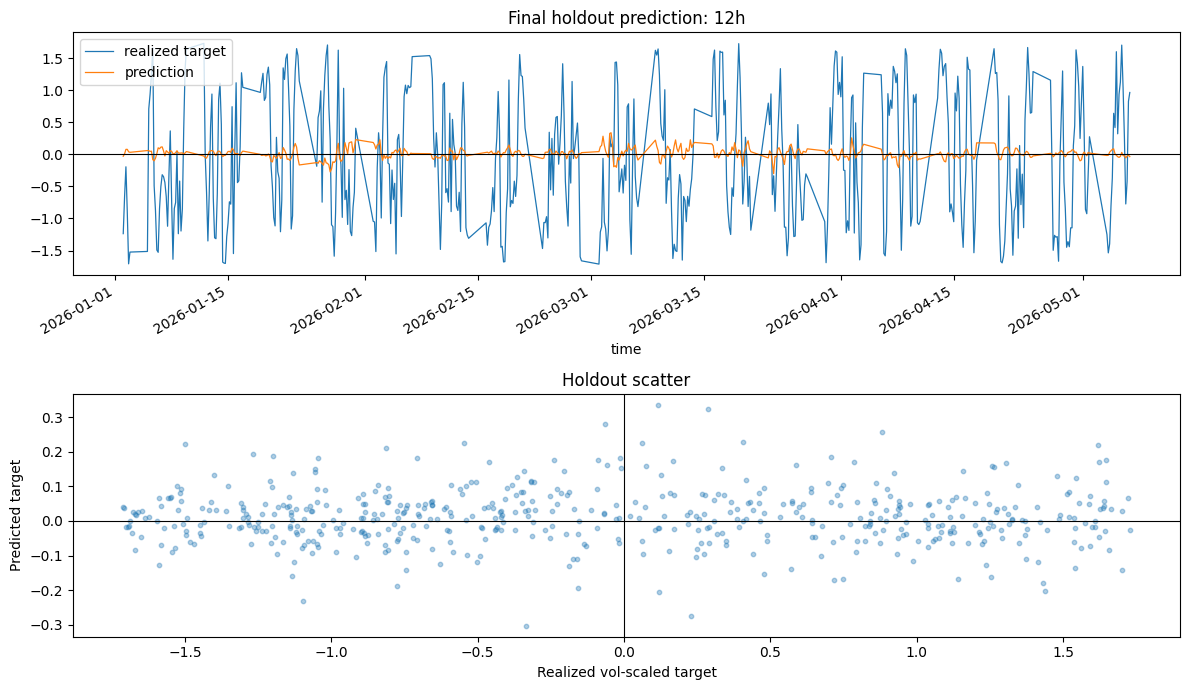

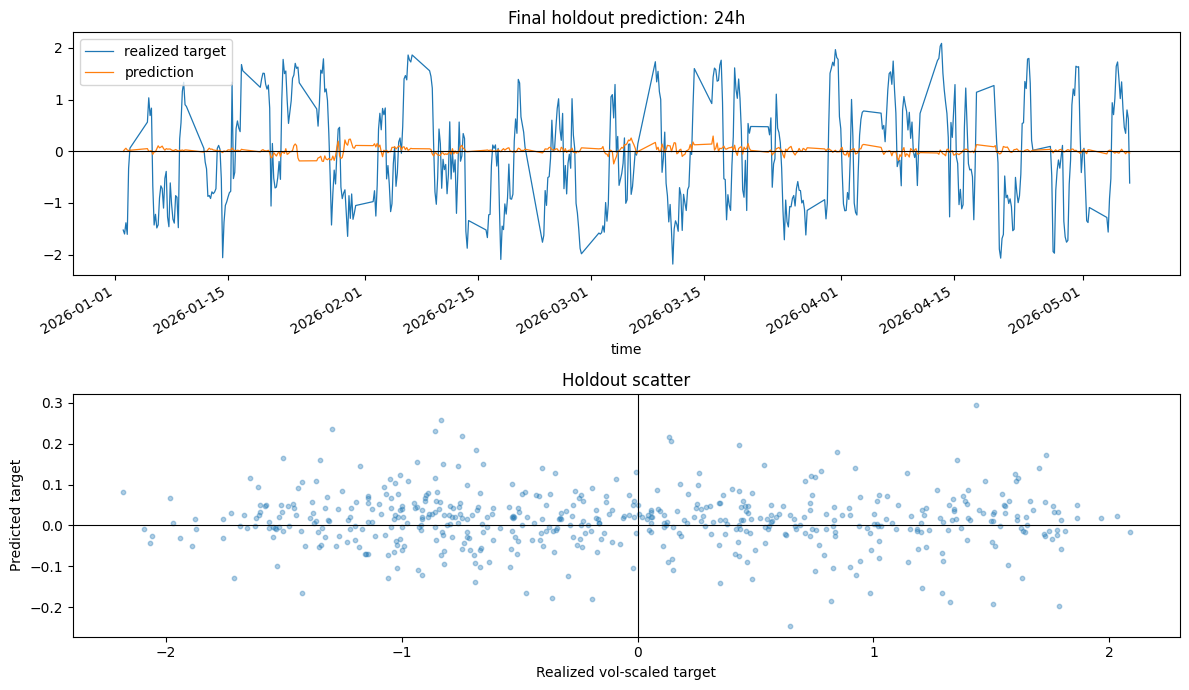

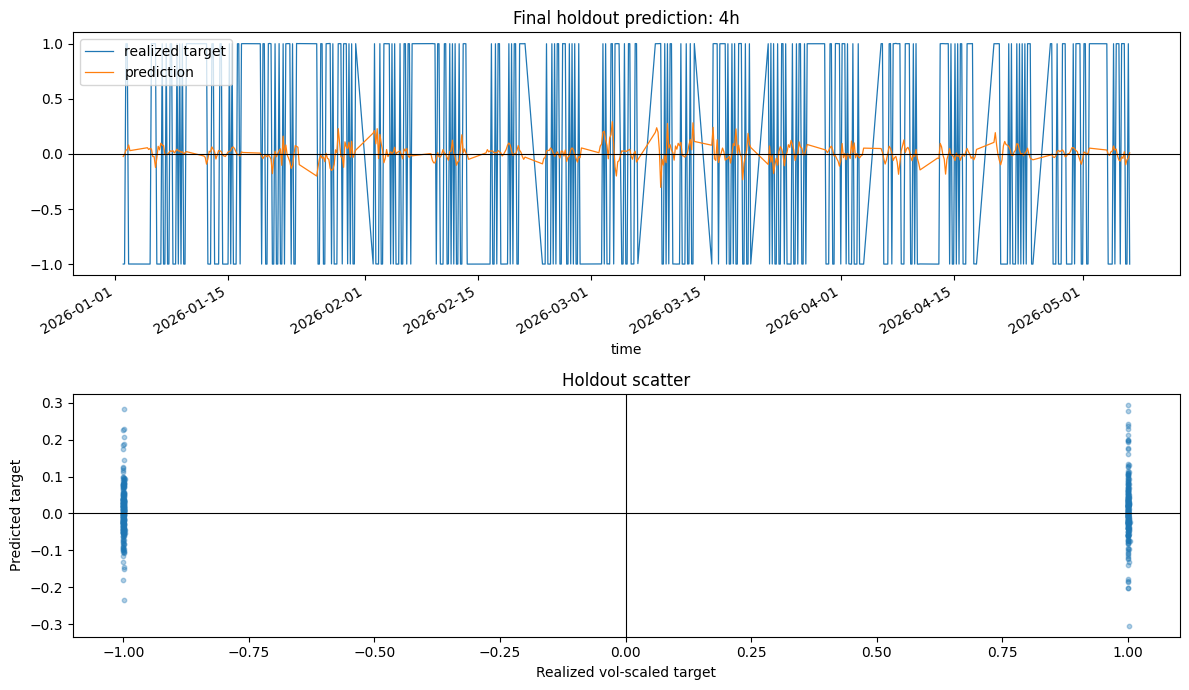

In [13]:
for horizon_label, model in final_models.items():
    cfg = model.config
    target_col = f"target_{horizon_label}"
    holdout = model_df.loc[model_df.index.year == holdout_year, list(cfg.feature_cols) + [target_col]].dropna()
    pred = pd.Series(model.predict_from_frame(holdout), index=holdout.index, name="prediction")

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
    holdout[target_col].plot(ax=axes[0], lw=0.9, label="realized target")
    pred.plot(ax=axes[0], lw=0.9, label="prediction")
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_title(f"Final holdout prediction: {horizon_label}")
    axes[0].legend()

    axes[1].scatter(holdout[target_col], pred, s=10, alpha=0.35)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].axvline(0, color="black", lw=0.8)
    axes[1].set_xlabel("Realized vol-scaled target")
    axes[1].set_ylabel("Predicted target")
    axes[1].set_title("Holdout scatter")
    plt.tight_layout()
    plt.show()

## 12. Comparison with Previous Shallow Tree Family

This section retrains shallow DecisionTree, RandomForest, and optional XGBoost models on the same Feature Group 1 state and the same walk-forward folds. It reports only statistical prediction metrics.

In [14]:
def tree_model_specs() -> Dict[str, object]:
    specs = {
        "DecisionTree_depth3": DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=RANDOM_STATE),
        "DecisionTree_depth4": DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=RANDOM_STATE),
        "RandomForest_depth3": RandomForestRegressor(
            n_estimators=300, max_depth=3, min_samples_leaf=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "RandomForest_depth4": RandomForestRegressor(
            n_estimators=300, max_depth=4, min_samples_leaf=100, random_state=RANDOM_STATE, n_jobs=-1
        ),
    }
    if HAS_XGBOOST:
        specs["XGBoost_depth3"] = XGBRegressor(
            n_estimators=250, max_depth=3, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
        )
        specs["XGBoost_depth4"] = XGBRegressor(
            n_estimators=250, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
        )
    return specs


def evaluate_sklearn_walk_forward(data: pd.DataFrame, horizon_label: str, model_name: str, estimator, feature_cols: List[str] = BASE_FEATURES):
    target_col = f"target_{horizon_label}"
    horizon_bars = HORIZONS[horizon_label]
    pred_frames = []

    for test_year in walk_forward_years(data.index, min_train_years=2):
        test_mask = data.index.year == test_year
        if not test_mask.any():
            continue
        test_start = data.index[test_mask].min()
        purge = pd.Timedelta(hours=4 * horizon_bars)
        train = data.loc[data.index < test_start - purge, feature_cols + [target_col]].dropna()
        test = data.loc[test_mask, feature_cols + [target_col]].dropna()
        if len(train) < 750 or len(test) < 100:
            continue

        scaler = StandardScaler().fit(train[feature_cols])
        X_train = scaler.transform(train[feature_cols])
        X_test = scaler.transform(test[feature_cols])
        est = clone(estimator)
        est.fit(X_train, train[target_col].to_numpy())
        pred = est.predict(X_test)
        pred_frames.append(pd.DataFrame({"y_true": test[target_col].to_numpy(), "y_pred": pred, "year": test_year}))

    if not pred_frames:
        return None
    pred_df = pd.concat(pred_frames, ignore_index=True)
    stats = prediction_metrics(pred_df["y_true"], pred_df["y_pred"])
    stats.update({"horizon": horizon_label, "model": model_name, "folds": pred_df["year"].nunique(), "n_oos": len(pred_df)})
    return pd.Series(stats)


tree_rows = []
for model_name, estimator in tree_model_specs().items():
    for horizon_label in HORIZONS:
        row = evaluate_sklearn_walk_forward(model_df, horizon_label, model_name, estimator, BASE_FEATURES)
        if row is not None:
            tree_rows.append(row)

tree_results = pd.DataFrame(tree_rows)

def best_sindy_for_tree_comparison(results: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in select_best_by_horizon(results).iterrows():
        rows.append({
            "horizon": row["horizon"],
            "model": "Best_PySINDy_" + row["config"],
            "rmse": row["rmse"],
            "mae": row["mae"],
            "pearson": row["pearson"],
            "spearman": row["spearman"],
            "directional_accuracy": row["directional_accuracy"],
            "folds": row["folds"],
            "n_oos": row["n_oos"],
        })
    return pd.DataFrame(rows)


model_comparison = pd.concat([best_sindy_for_tree_comparison(sindy_results), tree_results], ignore_index=True)
model_comparison = model_comparison.sort_values(["horizon", "spearman", "pearson"], ascending=[True, False, False])
display(model_comparison.round(4))

model_comparison.to_csv(OUTPUT_DIR / "eurusd_h4_group1_pysindy_vs_shallow_trees.csv", index=False)

,horizon,model,rmse,mae,pearson,spearman,directional_accuracy,folds,n_oos,r2
0,12h,Best_PySINDy_poly2_stlsq_002,1.0005,0.8727,0.0138,0.0297,0.5021,6,8276,NaN
4,12h,DecisionTree_depth3,0.9920,0.8690,0.0270,0.0272,0.5051,6,8276,-0.0101
10,12h,RandomForest_depth3,0.9887,0.8670,0.0246,0.0235,0.5022,6,8276,-0.0034
13,12h,RandomForest_depth4,0.9894,0.8673,0.0221,0.0220,0.5045,6,8276,-0.0049
7,12h,DecisionTree_depth4,0.9950,0.8701,0.0189,0.0147,0.4960,6,8276,-0.0163
19,12h,XGBoost_depth4,0.9977,0.8716,0.0198,0.0135,0.5007,6,8276,-0.0217
16,12h,XGBoost_depth3,0.9947,0.8701,0.0173,0.0105,0.4978,6,8276,-0.0157
1,24h,Best_PySINDy_poly2_stlsq_005,0.9848,0.8307,0.0166,0.0186,0.5058,6,8276,NaN
8,24h,DecisionTree_depth4,0.9790,0.8266,0.0176,0.0144,0.5052,6,8276,-0.0188
20,24h,XGBoost_depth4,0.9845,0.8298,0.0090,0.0089,0.5076,6,8276,-0.0302


## 13. Degree-2 Regularization Path: Which Terms Survive?

This section performs a focused regularization path analysis on the **degree-2 polynomial library only**, using the 24h horizon (the most stable target). The goal is to separate pure polynomial terms from custom interactions and show which terms survive as we increase both:

1. **STLSQ threshold** (sparsity penalty)
2. **Ridge alpha** (L2 coefficient shrinkage)

The analysis trains on all data except 2026 and reports:
- Active term counts
- Top surviving terms at each regularization level
- Coefficient stability across the path

This helps identify whether the discovered relationships are driven by low-order polynomial structure or require engineered interactions.

In [16]:
def regularization_path_analysis(
    data: pd.DataFrame, 
    horizon_label: str, 
    feature_cols: List[str],
    thresholds: List[float],
    alphas: List[float],
    holdout_year: int = 2026
) -> Tuple[pd.DataFrame, Dict]:
    """
    Sweep through STLSQ threshold and ridge alpha combinations for degree-2 polynomial library.
    Returns a summary DataFrame and a dictionary of fitted models.
    """
    target_col = f"target_{horizon_label}"
    train = data.loc[data.index.year < holdout_year, feature_cols + [target_col]].dropna()
    test = data.loc[data.index.year == holdout_year, feature_cols + [target_col]].dropna()
    
    scaler = StandardScaler().fit(train[feature_cols])
    X_train = scaler.transform(train[feature_cols])
    X_test = scaler.transform(test[feature_cols])
    y_train = train[target_col].to_numpy()
    y_test = test[target_col].to_numpy()
    
    library = ps.PolynomialLibrary(degree=2, include_bias=True)
    theta_train = np.asarray(library.fit_transform(X_train))
    theta_test = np.asarray(library.transform(X_test))
    term_names = library.get_feature_names(feature_cols)
    
    results = []
    models = {}
    
    for threshold in thresholds:
        for alpha in alphas:
            optimizer = ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=False)
            optimizer.fit(theta_train, y_train.reshape(-1, 1))
            coef = np.asarray(optimizer.coef_).reshape(-1)
            
            pred_train = theta_train @ coef
            pred_test = theta_test @ coef
            
            active_mask = np.abs(coef) > 1e-10
            n_active = int(active_mask.sum())
            
            train_stats = prediction_metrics(y_train, pred_train)
            test_stats = prediction_metrics(y_test, pred_test)
            
            # Categorize active terms
            active_terms = [term_names[i] for i in range(len(term_names)) if active_mask[i]]
            n_bias = sum(1 for t in active_terms if t == "1")
            n_linear = sum(1 for t in active_terms if "^" not in t and " " not in t and t != "1")
            n_quadratic = sum(1 for t in active_terms if "^2" in t)
            n_interaction = sum(1 for t in active_terms if " " in t and "^2" not in t)
            
            results.append({
                "threshold": threshold,
                "alpha": alpha,
                "n_active": n_active,
                "n_bias": n_bias,
                "n_linear": n_linear,
                "n_quadratic": n_quadratic,
                "n_interaction": n_interaction,
                "train_rmse": train_stats["rmse"],
                "train_spearman": train_stats["spearman"],
                "train_r2": train_stats["r2"],
                "test_rmse": test_stats["rmse"],
                "test_mae": test_stats["mae"],
                "test_spearman": test_stats["spearman"],
                "test_pearson": test_stats["pearson"],
                "test_directional": test_stats["directional_accuracy"],
                "test_r2": test_stats["r2"],
            })
            
            models[(threshold, alpha)] = {
                "coef": coef,
                "term_names": term_names,
                "active_mask": active_mask,
                "optimizer": optimizer,
            }
    
    return pd.DataFrame(results), models


# Define regularization path grid
THRESHOLDS = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.3, 0.5]
ALPHAS = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]

print("Running degree-2 regularization path analysis for 24h horizon...")
path_results, path_models = regularization_path_analysis(
    data=model_df,
    horizon_label="24h",
    feature_cols=BASE_FEATURES,
    thresholds=THRESHOLDS,
    alphas=ALPHAS,
    holdout_year=2026
)

print("\n" + "="*100)
print("Regularization Path Summary: Degree-2 Polynomial Library, 24h Horizon")
print("="*100)
display(path_results.round(4))

# Show top terms at selected regularization levels
print("\n" + "="*100)
print("Top Terms at Selected Regularization Levels")
print("="*100)

selected_configs = [
    (0.01, 0.001, "Low regularization (baseline)"),
    (0.05, 0.001, "Medium STLSQ threshold"),
    (0.10, 0.01, "High STLSQ + High Ridge"),
    (0.20, 0.05, "Very high regularization"),
]

for threshold, alpha in zip(THRESHOLDS, ALPHAS):
    if (threshold, alpha) not in path_models:
        continue
    
    model = path_models[(threshold, alpha)]
    coef = model["coef"]
    term_names = model["term_names"]
    active_mask = model["active_mask"]
    
    eq_df = pd.DataFrame({
        "term": [term_names[i] for i in range(len(term_names)) if active_mask[i]],
        "coef": [coef[i] for i in range(len(coef)) if active_mask[i]],
    })
    eq_df["abs_coef"] = eq_df["coef"].abs()
    eq_df = eq_df.sort_values("abs_coef", ascending=False).head(15)
    
    #print(f"\n{description} | threshold={threshold}, alpha={alpha}")
    print(f"Active terms: {int(active_mask.sum())}")
    display(eq_df[["term", "coef"]].reset_index(drop=True))

# Save results
path_results.to_csv(OUTPUT_DIR / "eurusd_h4_24h_degree2_regularization_path.csv", index=False)
print(f"\nSaved regularization path results to: {OUTPUT_DIR / 'eurusd_h4_24h_degree2_regularization_path.csv'}")

Running degree-2 regularization path analysis for 24h horizon...

Regularization Path Summary: Degree-2 Polynomial Library, 24h Horizon


,threshold,alpha,n_active,n_bias,n_linear,n_quadratic,n_interaction,train_rmse,train_spearman,train_r2,test_rmse,test_mae,test_spearman,test_pearson,test_directional,test_r2
0,0.01,0.0001,61,1,5,10,45,0.9630,0.0922,0.0101,1.0286,0.8836,-0.0182,-0.0263,0.4784,-0.0141
1,0.01,0.0010,61,1,5,10,45,0.9630,0.0922,0.0101,1.0286,0.8836,-0.0182,-0.0263,0.4784,-0.0141
2,0.01,0.0050,60,1,5,10,44,0.9630,0.0920,0.0101,1.0286,0.8836,-0.0167,-0.0259,0.4765,-0.0140
3,0.01,0.0100,59,1,5,10,43,0.9630,0.0920,0.0101,1.0287,0.8837,-0.0171,-0.0271,0.4747,-0.0142
4,0.01,0.0500,60,1,6,10,43,0.9630,0.0920,0.0101,1.0287,0.8837,-0.0141,-0.0272,0.4803,-0.0142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.50,0.0100,0,0,0,0,0,0.9679,NaN,-0.0000,1.0240,0.8810,NaN,NaN,0.0000,-0.0050
60,0.50,0.0500,0,0,0,0,0,0.9679,NaN,-0.0000,1.0240,0.8810,NaN,NaN,0.0000,-0.0050
61,0.50,0.1000,0,0,0,0,0,0.9679,NaN,-0.0000,1.0240,0.8810,NaN,NaN,0.0000,-0.0050
62,0.50,0.5000,0,0,0,0,0,0.9679,NaN,-0.0000,1.0240,0.8810,NaN,NaN,0.0000,-0.0050



Top Terms at Selected Regularization Levels
Active terms: 61


,term,coef
0,ewma_ret_5^2,8.825944
1,ewma_ret_5 ewma_ret_10,-8.737975
2,ewma_ret_10^2,7.791345
3,ewma_ret_10 ewma_ret_20,-5.782020
4,ret_10 ewma_ret_10,-4.085603
5,ret_2 ewma_ret_5,-3.994355
6,ewma_ret_5 ewma_ret_20,3.086696
7,ret_3 ewma_ret_5,-3.070713
8,ret_5 ewma_ret_5,-2.941487
9,ret_1 ewma_ret_5,-2.585869


Active terms: 54


...

Active terms: 0


,term,coef


Active terms: 0


,term,coef



Saved regularization path results to: C:\Users\Hermes\PycharmProjects\metalib\metalib\notebooks\true_opens\eurusd_h4_24h_degree2_regularization_path.csv


In [17]:
path_results

,threshold,alpha,n_active,n_bias,n_linear,n_quadratic,n_interaction,train_rmse,train_spearman,train_r2,test_rmse,test_mae,test_spearman,test_pearson,test_directional,test_r2
0,0.01,0.0001,61,1,5,10,45,0.962994,0.092156,0.010117,1.028635,0.883589,-0.018188,-0.026266,0.478424,-0.014099
1,0.01,0.0010,61,1,5,10,45,0.962994,0.092156,0.010117,1.028635,0.883589,-0.018188,-0.026266,0.478424,-0.014099
2,0.01,0.0050,60,1,5,10,44,0.962995,0.091958,0.010115,1.028598,0.883592,-0.016693,-0.025853,0.476548,-0.014027
3,0.01,0.0100,59,1,5,10,43,0.962995,0.091962,0.010114,1.028693,0.883656,-0.017060,-0.027115,0.474672,-0.014214
4,0.01,0.0500,60,1,6,10,43,0.962995,0.092012,0.010115,1.028690,0.883687,-0.014150,-0.027209,0.480300,-0.014208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.50,0.0100,0,0,0,0,0,0.967918,NaN,-0.000032,1.023985,0.881008,NaN,NaN,0.000000,-0.004951
60,0.50,0.0500,0,0,0,0,0,0.967918,NaN,-0.000032,1.023985,0.881008,NaN,NaN,0.000000,-0.004951
61,0.50,0.1000,0,0,0,0,0,0.967918,NaN,-0.000032,1.023985,0.881008,NaN,NaN,0.000000,-0.004951
62,0.50,0.5000,0,0,0,0,0,0.967918,NaN,-0.000032,1.023985,0.881008,NaN,NaN,0.000000,-0.004951


In [ ]:
# Visualize regularization path
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Active terms vs threshold (for each alpha)
for alpha in ALPHAS:
    subset = path_results[path_results["alpha"] == alpha]
    axes[0, 0].plot(subset["threshold"], subset["n_active"], marker="o", label=f"alpha={alpha}")
axes[0, 0].set_xlabel("STLSQ Threshold")
axes[0, 0].set_ylabel("Number of Active Terms")
axes[0, 0].set_title("Sparsity Path: Active Terms vs Threshold")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Term type breakdown at alpha=0.001
subset = path_results[path_results["alpha"] == 0.001]
axes[0, 1].plot(subset["threshold"], subset["n_linear"], marker="s", label="Linear")
axes[0, 1].plot(subset["threshold"], subset["n_quadratic"], marker="^", label="Quadratic")
axes[0, 1].plot(subset["threshold"], subset["n_interaction"], marker="o", label="Interaction")
axes[0, 1].set_xlabel("STLSQ Threshold")
axes[0, 1].set_ylabel("Number of Terms")
axes[0, 1].set_title("Term Type Breakdown (alpha=0.001)")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Test Spearman IC vs threshold
for alpha in ALPHAS:
    subset = path_results[path_results["alpha"] == alpha]
    axes[1, 0].plot(subset["threshold"], subset["test_spearman"], marker="o", label=f"alpha={alpha}")
axes[1, 0].set_xlabel("STLSQ Threshold")
axes[1, 0].set_ylabel("Test Spearman IC")
axes[1, 0].set_title("Out-of-Sample Spearman IC vs Regularization")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(0, color="black", lw=0.8, linestyle="--")

# Plot 4: Test RMSE vs number of active terms
axes[1, 1].scatter(path_results["n_active"], path_results["test_rmse"], 
                   c=path_results["test_spearman"], cmap="RdYlGn", s=50, alpha=0.7)
axes[1, 1].set_xlabel("Number of Active Terms")
axes[1, 1].set_ylabel("Test RMSE")
axes[1, 1].set_title("Pareto Frontier: RMSE vs Sparsity")
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label("Test Spearman IC", fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("Regularization Path Analysis Complete")
print("="*100)
print(f"Total configurations tested: {len(path_results)}")
print(f"Threshold range: {min(THRESHOLDS)} to {max(THRESHOLDS)}")
print(f"Alpha range: {min(ALPHAS)} to {max(ALPHAS)}")
print(f"\nBest test Spearman IC: {path_results['test_spearman'].max():.4f}")
best_idx = path_results["test_spearman"].idxmax()
best_config = path_results.iloc[best_idx]
print(f"  threshold={best_config['threshold']}, alpha={best_config['alpha']}, n_active={int(best_config['n_active'])}")

In [ ]:
## 14. Interpretation and Conclusion Template

Use the tables and equations above to document the final interpretation after a fresh run.

Checklist:

- Which horizon has the strongest out-of-sample IC after accounting for sparsity and coefficient stability?
- Are the dominant terms simple momentum effects, mean-reversion effects, or nonlinear interactions?
- Do selected terms keep their sign across calendar folds?
- Does a more complex library materially improve OOS statistics, or does it only add unstable coefficients?
- Does the sparse equation remain competitive with shallow tree models on RMSE, MAE, Pearson, Spearman, and directional accuracy?

Recommended conclusion structure:

1. Best horizon: choose the horizon with the best balance of Spearman IC, Pearson IC, directional accuracy, and stability.
2. Best sparse library: prefer the simplest stable equation. Reject polynomial degree 3 if it adds terms without improving OOS IC.
3. Equation interpretation: state the dominant signed terms and whether they imply continuation, reversal, or state-dependent momentum.
4. Stability assessment: report coefficient CV, sign consistency, and years where the relationship weakened.
5. Comparison to shallow trees: compare only RMSE, MAE, Pearson, Spearman, and directional accuracy.
6. Next improvements: test ex-ante volatility scaling, robust losses, alternative fold lengths, term-selection bootstraps, and regime-conditioned sparse libraries.

Do not add strategy, position, Sharpe, P/L, or portfolio metrics to this notebook.

report = {
    "data_start": str(model_df.index.min()),
    "data_end": str(model_df.index.max()),
    "rows": int(len(model_df)),
    "best_sindy": best_sindy[summary_cols].round(6).to_dict(orient="records"),
    "final_holdout_stats": final_holdout_stats.round(6).to_dict(orient="records"),
    "equations": {h: format_sparse_equation(m, max_terms=25) for h, m in final_models.items()},
}

for key, value in report.items():
    print(f"\n{key}")
    print(value)